# Code for import, analyse, and produce figure on the contracted graph

## Preamble

### Packages import

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from mpl_chord_diagram import chord_diagram

useLatex = True

### Constants definitions

In [ ]:
UU_color = '#D95319'
EE_color = '#0072BD'
UE_color = '#77AC30'
EU_color = '#7E2F8E'

UU1_color = '#FF6347'
UU2_color = '#FFC0CB'
UU3_color = '#FF7F00'
UU4_color = '#FFA500'

yellowYed = '#FFCC00'
greenYed  = '#99CC00'
greyYed   = '#CCCCCC'
orangeM   = '#D95319'
blueM     = '#0072BD'
greenM    = '#77AC30'
cyanM     = '#4DBEEE'
purpleM   = '#7E2F8E'
yellowM   = '#EDB120'

black     = '#0B0B0B'
darkGray  = '#313232'

greenUSD  = '#07911C'
greenUSD  = yellowM

qs = [
    'Aug\'20',
    'Sept\'20',
    'Oct\'20',
    'Nov\'20',
    'Dec\'20',
    'Jan\'21',
    'Feb\'21',
    'Mar\'21',
    'Apr\'21',
    'May\'21',
    'June\'21',
    'July\'21',
    'Aug\'21',
    'Sept\'21',
    'Oct\'21',
    'Nov\'21',
    'Dec\'21',
    'Jan\'22',
    'Feb\'22',
    'Mar\'22',
    'Apr\'22',
    'May\'22',
    'June\'22',
    'July\'22',
    'Aug\'22',
    'Sept\'22'
]

plt.rcParams.update({
    "text.usetex": useLatex,
    'font.size': 12,
#    "font.family" : "sans-serif",
#    "font.serif" : ["Computer Modern Serif"],
#    "font.sans-serif" : ["Computer Modern"]
})

data_dir = './data/'
do_export = False
imgfolder = 'img/'

### Define the Colours etiquettes

 - c=0 are unclassified users
 - c>0 are the different Exchange Services

In [3]:
names = {
    0  : '',
    1  : 'Binance',
    2  : 'Kraken.com',
    3  : 'Huobi.com',
    4  : 'Kucoin.com',
    5  : 'Okx.com',
    6  : '\\textbf{Unknown 1}',
    7  : 'Coinbase.com',
    8  : 'CoinEx',
    9  : 'Gate.io',
    10 : '\\textbf{Unknown 2}',
    11 : 'Nexo',
    12 : '\\textbf{Unknown 3}',
    13 : 'ChangeNow.io',
    14 : 'HitBTC',
    15 : 'Bitfinex.com',
    16 : 'ByBit.com',
    17 : 'FTX.COM',
    18 : '\\textbf{Unknown 6}',
    19 : 'MEXC Global',
    20 : '\\textbf{Unknown 5}',
    21 : '\\textbf{Unknown 4}',
    22 : '\\textbf{Unknown 8}',
    23 : '\\textbf{Unknown 7}',
    24 : 'OceanEx',
    25 : 'Polkaholic',
    26 : '\\textbf{Unknown 9}',
    27 : '\\textbf{Unknown A}',
    28 : '\\textbf{Unknown B}',
    29 : '\\textbf{Unknown C}',
    30 : '\\textbf{Unknown D}',
    31 : '\\textbf{Unknown E}',
    32 : '\\textbf{Unknown F}',
    33 : '\\textbf{Unknown 0}',
}

### Graph and mapping import

The contracted graph `G1` is a `Networkx DiGraph` where nodes represents clusters and edges represents sets of inter-cluster transactions.  
For each month (in [0..25]) the monthly contracted subgraph is obtained from the subgraph of transactions occurred within that specific month.
Monthly subgraphs are stored in `G1s`.

The original graph `G` (and the corresponding monthly subgraphs `Gs`) is not provided here;
if you are interested in the complete dataset, please contact the corresponding author sending an email to [Maurantonio Caprolu](<mailto:maurantonio.caprolu@kaust.edu.sa>).

Clusters information are stored as node weights:
 - `avc`: Number of vertices inside the cluster
 - `aec`: Number of the occurred intra-cluster transactions
 - `aef`: Value of the occurred intra-cluster transactions

Transactions information are stored as edge weights:
 - `ec`: Number of the inter-cluster transactions
 - `ef`: Value of the occurred inter-cluster transactions

Mapping between nodes' hash (as per Polkadot ledger) and index within the contracted graph(s) are saved within `H_2_V1` files.

In [4]:
G1s = {}
H_2_V1s = {}
V_2_V1s = {}

nq = 26

for i in range(nq):
    graph_final_filename = f'{data_dir}/monthly_graphs/M{i}_contracted_graph.gpickle'
    H2V1_filename = f'{data_dir}/monthly_graphs/M{i}_H2V1.txt'

    
    with open(graph_final_filename, 'rb') as f:
        G1s[i] = pickle.load(f)

    H_2_V1 = {}
    with open(H2V1_filename, 'r') as fp:
        for line in fp:
            ll = line.split(" : ")
            H_2_V1[ll[0]] = int(ll[1].split("\n")[0])
    
    H_2_V1s[i] = H_2_V1

graph_final_filename = f'{data_dir}/full_graph/full_contracted_graph.gpickle'
with open(graph_final_filename, 'rb') as f:
    G1 = pickle.load(f)

H2V1_filename = f'{data_dir}/full_graph/full_H2V1.txt'
H_2_V1 = {}
with open(H2V1_filename, 'r') as fp:
    for line in fp:
        ll = line.split(" : ")
        H_2_V1[ll[0]] = int(ll[1].split("\n")[0])


N1s = {i : G1s[i].order() for i in range(nq)}
N1  = G1.order()

### Import marketcap data

 - `dot_marketcap.pickle`: holds the monthly average value of DOT-USD exchange and the total capitalisation (in USD) of Polkadot.
 e.g.: (month, year, dot value, polkadot capitalization)
   ```py
   [[8, 2020, 5.363166495, 2084084066.42], [9, 2020, 4.6091272325, 3929961755.3925004],....]
   ```

 - `crypto_marketcap.pickle`: capitalization (USD) of the entire crypto-market.
 e.g.: (month, year, capitalization)
   ```py
   [[8, 2020, 359459790580.42865], [9, 2020, 345051980090.8693],...]
   ```

In [5]:
with open(f'{data_dir}/capitalization/dot_marketcap.pickle', 'rb') as f:
    dotcapdata = pickle.load(f)
with open(f'{data_dir}/capitalization/crypto_marketcap.pickle', 'rb') as f:
    allcapdata = pickle.load(f)

In [6]:
dot2usd = np.array([x[2] for x in dotcapdata[:nq]])
dot2cap = np.array([x[3] for x in dotcapdata[:nq]])
all2cap = np.array([x[2] for x in allcapdata[:nq]])

## Process data

In [7]:
# User clusters with size
ucls_1   = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']==1]
ucls_2   = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']==2]
ucls_3   = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']==3]
ucls_10  = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']>3 and G1.nodes[i]['avc']<=10]
ucls_100 = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']>10 and G1.nodes[i]['avc']<=100]
ucls_421 = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']>100 and G1.nodes[i]['avc']<=421]
ucls_big = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']==568823]

assert [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']>421 and G1.nodes[i]['avc']<568823] == []

# All exchanges clusters
ecls_all = [i for i in range(N1) if G1.nodes[i]['c']!=0]

In [8]:
sizes  = [G1.nodes[i]['avc'] for i in ecls_all]
srt = [i[0] for i in sorted(enumerate(sizes), key=lambda x:x[1], reverse=True)]
ecls_top_10 = [ecls_all[srt[i]] for i in range(10)]

In [9]:
# User vertex count with size x
uvc_1   = sum([G1.nodes[i]['avc'] for i in ucls_1  ])
uvc_2   = sum([G1.nodes[i]['avc'] for i in ucls_2  ])
uvc_3   = sum([G1.nodes[i]['avc'] for i in ucls_3  ])
uvc_10  = sum([G1.nodes[i]['avc'] for i in ucls_10 ])
uvc_100 = sum([G1.nodes[i]['avc'] for i in ucls_100])
uvc_421 = sum([G1.nodes[i]['avc'] for i in ucls_421])
uvc_big = sum([G1.nodes[i]['avc'] for i in ucls_big])
uvc_tot = uvc_1 + uvc_2 + uvc_3 + uvc_10 + uvc_100 + uvc_421 + uvc_big
# User vertex count with size x
uec_1   = sum([G1.nodes[i]['aec'] for i in ucls_1  ])
uec_2   = sum([G1.nodes[i]['aec'] for i in ucls_2  ])
uec_3   = sum([G1.nodes[i]['aec'] for i in ucls_3  ])
uec_10  = sum([G1.nodes[i]['aec'] for i in ucls_10 ])
uec_100 = sum([G1.nodes[i]['aec'] for i in ucls_100])
uec_421 = sum([G1.nodes[i]['aec'] for i in ucls_421])
uec_big = sum([G1.nodes[i]['aec'] for i in ucls_big])
uec_tot = uec_1 + uec_2 + uec_3 + uec_10 + uec_100 + uec_421 + uec_big
# User vertex count with size x
uef_1   = sum([G1.nodes[i]['aef'] for i in ucls_1  ])
uef_2   = sum([G1.nodes[i]['aef'] for i in ucls_2  ])
uef_3   = sum([G1.nodes[i]['aef'] for i in ucls_3  ])
uef_10  = sum([G1.nodes[i]['aef'] for i in ucls_10 ])
uef_100 = sum([G1.nodes[i]['aef'] for i in ucls_100])
uef_421 = sum([G1.nodes[i]['aef'] for i in ucls_421])
uef_big = sum([G1.nodes[i]['aef'] for i in ucls_big])
uef_tot = uef_1 + uef_2 + uef_3 + uef_10 + uef_100 + uef_421 + uef_big

## Users Distribution (w.r.t. cluster sizes) with Corresponding Statistics (Tab.3)

In [10]:
print("Size - num trans - [%] - mean - std")
print(f"1 - {uvc_1} - {uvc_1/uvc_tot*100:4.2f} - {uvc_1/len(ucls_1):4.2f} - {np.std([G1.nodes[i]['avc'] for i in ucls_1  ]):.2f}")
print(f"2 - {uvc_2} - {uvc_2/uvc_tot*100:4.2f} - {uvc_2/len(ucls_2):4.2f} - {np.std([G1.nodes[i]['avc'] for i in ucls_2  ]):.2f}")
print(f"3 - {uvc_3} - {uvc_3/uvc_tot*100:4.2f} - {uvc_3/len(ucls_3):4.2f} - {np.std([G1.nodes[i]['avc'] for i in ucls_3  ]):.2f}")
print(f"10 - {uvc_10} - {uvc_10/uvc_tot*100:4.2f} - {uvc_10/len(ucls_10):4.2f} - {np.std([G1.nodes[i]['avc'] for i in ucls_10  ]):.2f}")
print(f"100 - {uvc_100} - {uvc_100/uvc_tot*100:4.2f} - {uvc_100/len(ucls_100):4.2f} - {np.std([G1.nodes[i]['avc'] for i in ucls_100  ]):.2f}")
print(f"421 - {uvc_421} - {uvc_421/uvc_tot*100:4.2f} - {uvc_421/len(ucls_421):4.2f} - {np.std([G1.nodes[i]['avc'] for i in ucls_421  ]):.2f}")
print(" - - - -")
print(f"big - {uvc_big} - {uvc_big/uvc_tot*100:4.2f} - {uvc_big/len(ucls_big):4.2f} - {np.std([G1.nodes[i]['avc'] for i in ucls_big  ]):.2f}")

Size - num trans - [%] - mean - std
1 - 533308 - 38.55 - 1.00 - 0.00
2 - 199648 - 14.43 - 2.00 - 0.00
3 - 45018 - 3.25 - 3.00 - 0.00
10 - 28573 - 2.07 - 4.82 - 1.32
100 - 6875 - 0.50 - 20.40 - 14.23
421 - 1277 - 0.09 - 182.43 - 104.75
 - - - -
big - 568823 - 41.11 - 568823.00 - 0.00


In [11]:
print("Size - num trans - [%] - mean - std")
print(f"1 - {uec_1} - {uec_1/uec_tot*100:4.2f} - {uec_1/len(ucls_1):4.2f} - {np.std([G1.nodes[i]['aec'] for i in ucls_1  ]):.2f}")
print(f"2 - {uec_2} - {uec_2/uec_tot*100:4.2f} - {uec_2/len(ucls_2):4.2f} - {np.std([G1.nodes[i]['aec'] for i in ucls_2  ]):.2f}")
print(f"3 - {uec_3} - {uec_3/uec_tot*100:4.2f} - {uec_3/len(ucls_3):4.2f} - {np.std([G1.nodes[i]['aec'] for i in ucls_3  ]):.2f}")
print(f"10 - {uec_10} - {uec_10/uec_tot*100:4.2f} - {uec_10/len(ucls_10):4.2f} - {np.std([G1.nodes[i]['aec'] for i in ucls_10  ]):.2f}")
print(f"100 - {uec_100} - {uec_100/uec_tot*100:4.2f} - {uec_100/len(ucls_100):4.2f} - {np.std([G1.nodes[i]['aec'] for i in ucls_100  ]):.2f}")
print(f"421 - {uec_421} - {uec_421/uec_tot*100:4.2f} - {uec_421/len(ucls_421):4.2f} - {np.std([G1.nodes[i]['aec'] for i in ucls_421  ]):.2f}")
print(" - - - -")
print(f"big - {uec_big} - {uec_big/uec_tot*100:4.2f} - {uec_big/len(ucls_big):4.2f} - {np.std([G1.nodes[i]['aec'] for i in ucls_big  ]):.2f}")

Size - num trans - [%] - mean - std
1 - 0 - 0.00 - 0.00 - 0.00
2 - 137147 - 7.91 - 1.37 - 1.00
3 - 47771 - 2.76 - 3.18 - 2.80
10 - 42986 - 2.48 - 7.25 - 14.89
100 - 17670 - 1.02 - 52.43 - 165.59
421 - 1994 - 0.12 - 284.86 - 299.64
 - - - -
big - 1485582 - 85.72 - 1485582.00 - 0.00


In [12]:
print("Size - value trans - [%] - mean - std")
print(f"1 - {uef_1:.2f} - {uef_1/uef_tot*100:4.2f} - {uef_1/len(ucls_1):4.2f} - {np.std([G1.nodes[i]['aef'] for i in ucls_1  ]):.2f}")
print(f"2 - {uef_2:.2f} - {uef_2/uef_tot*100:4.2f} - {uef_2/len(ucls_2):4.2f} - {np.std([G1.nodes[i]['aef'] for i in ucls_2  ]):.2f}")
print(f"3 - {uef_3:.2f} - {uef_3/uef_tot*100:4.2f} - {uef_3/len(ucls_3):4.2f} - {np.std([G1.nodes[i]['aef'] for i in ucls_3  ]):.2f}")
print(f"10 - {uef_10:.2f} - {uef_10/uef_tot*100:4.2f} - {uef_10/len(ucls_10):4.2f} - {np.std([G1.nodes[i]['aef'] for i in ucls_10  ]):.2f}")
print(f"100 - {uef_100:.2f} - {uef_100/uef_tot*100:4.2f} - {uef_100/len(ucls_100):4.2f} - {np.std([G1.nodes[i]['aef'] for i in ucls_100  ]):.2f}")
print(f"421 - {uef_421:.2f} - {uef_421/uef_tot*100:4.2f} - {uef_421/len(ucls_421):4.2f} - {np.std([G1.nodes[i]['aef'] for i in ucls_421  ]):.2f}")
print(" - - - -")
print(f"big - {uef_big:.2f} - {uef_big/uef_tot*100:4.2f} - {uef_big/len(ucls_big):4.2f} - {np.std([G1.nodes[i]['aef'] for i in ucls_big  ]):.2f}")

Size - value trans - [%] - mean - std
1 - 0.00 - 0.00 - 0.00 - 0.00
2 - 15342087.65 - 0.79 - 153.69 - 6923.79
3 - 13178658.97 - 0.68 - 878.23 - 22425.36
10 - 51428936.40 - 2.64 - 8672.67 - 237931.70
100 - 13266104.15 - 0.68 - 39365.29 - 225851.09
421 - 30821.84 - 0.00 - 4403.12 - 6515.35
 - - - -
big - 1851260928.00 - 95.20 - 1851260928.00 - 0.00


## Market trend of the Polkadot cryptocurrency (Fig.2)

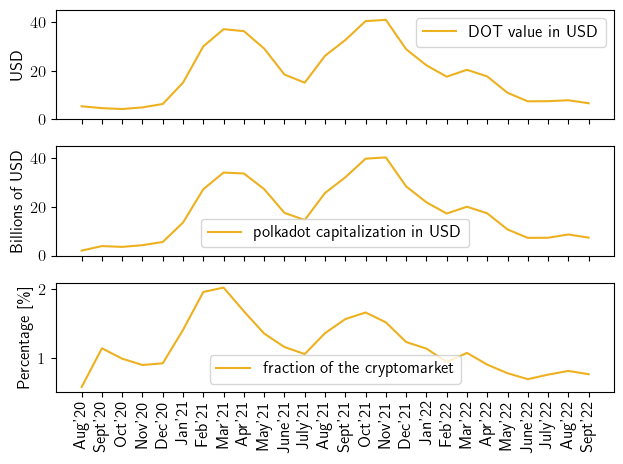

In [13]:
fig, axs = plt.subplots(3, 1, sharex=True)
axs[0].plot(dot2usd, label="DOT value in USD", color=greenUSD)
axs[0].legend()
axs[0].set_ylabel("USD")
axs[0].set_ylim([0, 45])

axs[1].plot(dot2cap/1000000000, label="polkadot capitalization in USD", color=greenUSD)
axs[1].legend()
axs[1].set_ylabel("Billions of USD")
axs[1].set_ylim([0, 45])

axs[2].plot(dot2cap/all2cap*100, label="fraction of the cryptomarket", color=greenUSD)
axs[2].legend(loc=8)
axs[2].set_ylabel("Percentage [\\%]")


axs[2].set_xticks(ticks=range(nq), labels=qs)
axs[2].tick_params(axis='x', rotation=90)

fig.tight_layout()

if do_export : fig.savefig(f'{imgfolder}/polkadot_capitalization.png', dpi=fig.dpi*5)

## Temporal distribution of the active nodes within the network (Fig.3)

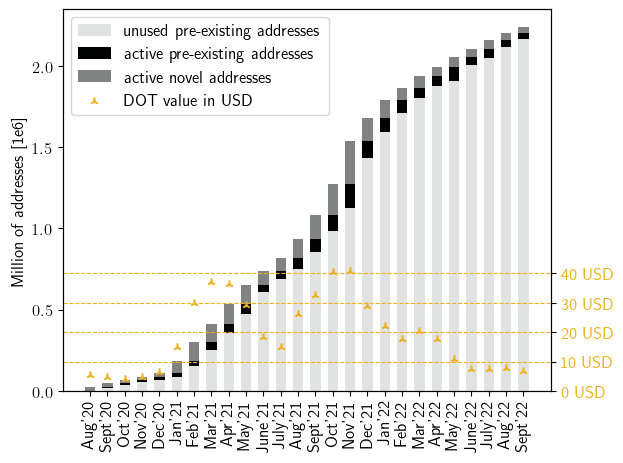

In [14]:
allnodes = set()

unused = np.zeros(nq)
novel  = np.zeros(nq)
old    = np.zeros(nq)

for i in range(nq):
    currnodes = set(H_2_V1s[i].keys())
    unused[i] = len(allnodes - currnodes)
    novel[i]  = len(currnodes - allnodes)
    old[i]    = len(currnodes) - novel[i]
    allnodes  = allnodes | currnodes

data = {
    'unused' : unused,
    'novel'  : novel,
    'old'    : old
}

cols = {
    'unused' : "#E1E2E2",
    'novel'  : "#818282",
    'old'    : "#010202"
}

labels = {
    'unused' : 'unused pre-existing addresses',
    'novel'  : 'active novel addresses',
    'old'    : 'active pre-existing addresses'
}

bars = {}

labelorder = ['unused', 'old', 'novel']

width = 0.6

fig, ax = plt.subplots()
bottom = np.zeros(nq)

for label in labelorder:
    count = data[label]
    bars[label] = ax.bar(qs, count/1000000, width, label=labels[label], bottom=bottom/1000000, color=cols[label])
    bottom += count

ax.set_ylabel('Million of addresses [1e6]')
ax.tick_params(axis='x', rotation=90)

axt = ax.twinx()
sct = axt.scatter(qs, dot2usd, marker='2', label="DOT value in USD", color=greenUSD)
axt.yaxis.set_label_coords(0.965, 0.14)
axt.tick_params(axis='y', labelcolor=greenUSD)
axt.set_ylim([0,130])
axt.set_yticks(ticks=[0, 10, 20, 30, 40], labels=["0 USD", "10 USD", "20 USD", "30 USD", "40 USD"])
axt.grid(True, axis='y', color=greenUSD, linestyle='--')

lns = [b for b in bars.values()] + [sct]
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc=0)

fig.tight_layout()
if do_export : fig.savefig(f'{imgfolder}/monthly_active_nodes.png', dpi=fig.dpi*5)

## Refinement of previous Figure, where nodes are divided between (blue) exchange and (orange) users (Fig.4) 

perold users = [0.         0.24841572 0.3991684  0.39850483 0.39194274 0.23762249
 0.23560595 0.35114419 0.36748391 0.39623764 0.43241966 0.42495918
 0.40138515 0.40868173 0.35608533 0.40215442 0.49352954 0.50680215
 0.5452443  0.53945867 0.57430788 0.5840279  0.54429671 0.49848036
 0.55500532 0.6026636 ], mu = 0.41906260652531. std = 0.13224395014226284
perold user weighted mu = 0.43082662541663874
perold exch = [0.         0.15802067 0.24125561 0.26133232 0.29313286 0.22734307
 0.19051836 0.20498103 0.20694252 0.24657676 0.2368699  0.27351168
 0.24696838 0.25869928 0.33123704 0.25712492 0.29927935 0.33697635
 0.47806464 0.36670888 0.42372996 0.53516272 0.42446841 0.48875666
 0.47080892 0.47266224], mu = 0.30504355837377795. std = 0.1213009034579303
perold user weighted mu = 0.31171188988212956


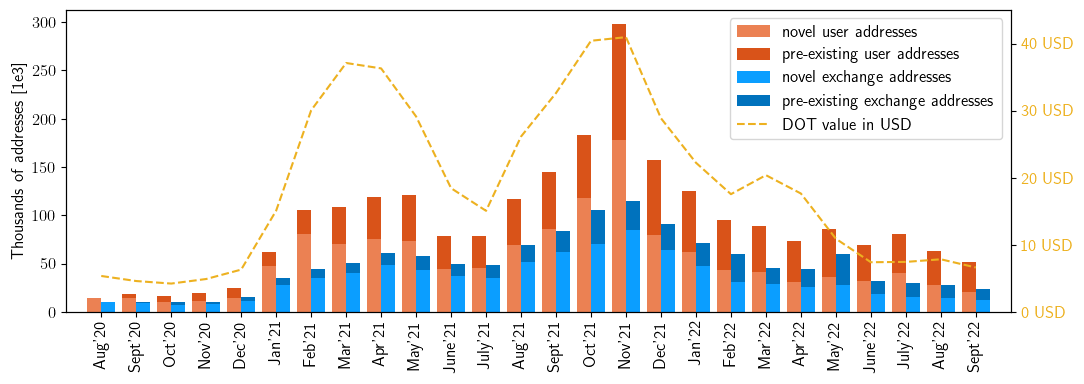

In [15]:

fig, ax = plt.subplots(figsize=(11,4))

labelorder = ['novel', 'old']
width = 0.4

pats = {
    'unused' : None,
    'novel'  : None,
    'old'    : None
}

labels = {
    'unused' : 'unused addresses',
    'novel'  : 'novel addresses',
    'old'    : 'pre-existing addresses'
}

barsU = {}
barsE = {}

### USERS

allnodes = set()
unused = np.zeros(nq)
novel  = np.zeros(nq)
old    = np.zeros(nq)
perold = np.zeros(nq)

for i in range(nq):
    currnodes = set([k for (k, v) in H_2_V1s[i].items() if G1s[i].nodes()[v]['c']==0])
    unused[i] = len(allnodes - currnodes)
    novel[i]  = len(currnodes - allnodes)
    old[i]    = len(currnodes) - novel[i]
    perold[i] = old[i] / (old[i] + novel[i])
    allnodes  = allnodes | currnodes

data = {
    'unused' : unused,
    'novel'  : novel,
    'old'    : old
}

cols = {
    'unused' : '#943911',
    'novel'  : '#EB8153',
    'old'    : UU_color
}

labels = {
    'unused' : 'unused user addresses',
    'novel'  : 'novel user addresses',
    'old'    : 'pre-existing user addresses'
}

bottom = np.zeros(nq)

for label in labelorder:
    count = data[label]
    barsU[label] = ax.bar(
        [x-.2 for x in range(nq)],
        count/1000,
        width,
        label=f'{labels[label]}',
        bottom=bottom/1000,
        color=cols[label],
        hatch=pats[label]
    )
    bottom += count

print(f"perold users = {perold}, mu = {np.mean(perold)}. std = {np.std(perold)}")
print(f"perold user weighted mu = {np.sum(old)/np.sum(old+novel)}")
    
### EXCHANGES
    
allnodes = set()

unused = np.zeros(nq)
novel  = np.zeros(nq)
old    = np.zeros(nq)
perold = np.zeros(nq)

for i in range(nq):
    currnodes = set([k for (k, v) in H_2_V1s[i].items() if G1s[i].nodes()[v]['c']>0])
    unused[i] = len(allnodes - currnodes)
    novel[i]  = len(currnodes - allnodes)
    old[i]    = len(currnodes) - novel[i]
    perold[i] = old[i] / (old[i] + novel[i])
    allnodes  = allnodes | currnodes

data = {
    'unused' : unused,
    'novel'  : novel,
    'old'    : old
}

labels = {
    'unused' : 'unused exchange addresses',
    'novel'  : 'novel exchange addresses',
    'old'    : 'pre-existing exchange addresses'
}

cols = {
    'unused' : '#004471',
    'novel'  : '#0B9EFF',
    'old'    : EE_color
}

bottom = np.zeros(nq)

for label in labelorder:
    count = data[label]
    barsE[label] = ax.bar(
        [x+.2 for x in range(nq)],
        count/1000,
        width,
        label=f'{labels[label]}',
        bottom=bottom/1000,
        color=cols[label],
        hatch=pats[label]
    )
    bottom += count

print(f"perold exch = {perold}, mu = {np.mean(perold)}. std = {np.std(perold)}")
print(f"perold user weighted mu = {np.sum(old)/np.sum(old+novel)}")

ax.set_ylabel('Thousands of addresses [1e3]')
plt.xticks(ticks=range(nq), labels=qs)
ax.tick_params(axis='x', rotation=90)
ax.set_xlim([-1, nq])

axt = ax.twinx()
lin = axt.plot(dot2usd, '--', label="DOT value in USD", color=greenUSD)
axt.yaxis.set_label_coords(0.982, 0.18)
axt.tick_params(axis='y', labelcolor=greenUSD)
axt.set_ylim([0,45])
axt.set_yticks(ticks=[0, 10, 20, 30, 40], labels=["0 USD", "10 USD", "20 USD", "30 USD", "40 USD"])

legel = [b for b in barsU.values()] + [b for b in barsE.values()] + lin
labs  = [k.get_label() for k in legel]
ax.legend(legel, labs)

fig.tight_layout()

if do_export : fig.savefig(f'{imgfolder}/monthly_active_users_exchanges.png', dpi=fig.dpi*5)

## Statistics of the inter- and intra-cluster interactions -- Flux (Fig.5)

In [16]:
f_uu_qs = np.array([
    sum([G1s[iq].nodes[i]['aef'] for i in range(N1s[iq]) if G1s[iq].nodes[i]['c']==0 and G1s[iq].nodes[i]['avc']>0])
    for iq in range(nq)
])
f_ee_inter_qs = np.array([
    sum([G1s[iq].nodes[i]['aef'] for i in range(N1s[iq]) if G1s[iq].nodes[i]['c']!=0]) for iq in range(nq)
])
f_ee_intra_qs = np.array([
    sum([
        c for (i, j, c) in G1s[iq].edges.data('ef')
        if c is not None and G1s[iq].nodes[i]['c'] > 0 and G1s[iq].nodes[j]['c'] > 0
    ]) 
    for iq in range(nq)
])
f_ee_qs = f_ee_inter_qs + f_ee_intra_qs
f_eu_qs = np.array([
    sum([
        c for (i, j, c) in G1s[iq].edges.data('ef')
        if c is not None and G1s[iq].nodes[i]['c'] > 0 and G1s[iq].nodes[j]['c'] == 0
    ])
    for iq in range(nq)
])
f_ue_qs = np.array([
    sum([
        c for (i, j, c) in G1s[iq].edges.data('ef')
        if c is not None and G1s[iq].nodes[i]['c'] == 0 and G1s[iq].nodes[j]['c'] > 0
    ])
    for iq in range(nq)
])


f_uu = sum([G1.nodes[i]['aef'] for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']>0])
f_ee_inter = sum([G1.nodes[i]['aef'] for i in range(N1) if G1.nodes[i]['c']!=0])
f_ee_intra = sum([
    c for (i, j, c) in G1.edges.data('ef')
    if c is not None and G1.nodes[i]['c'] > 0 and G1.nodes[j]['c'] > 0
])
f_ee = f_ee_inter+f_ee_intra
f_eu = sum([
    c for (i, j, c) in G1.edges.data('ef')
    if c is not None and G1.nodes[i]['c'] > 0 and G1.nodes[j]['c'] == 0
])
f_ue = sum([
    c for (i, j, c) in G1.edges.data('ef')
    if c is not None and G1.nodes[i]['c'] == 0 and G1.nodes[j]['c'] > 0
])

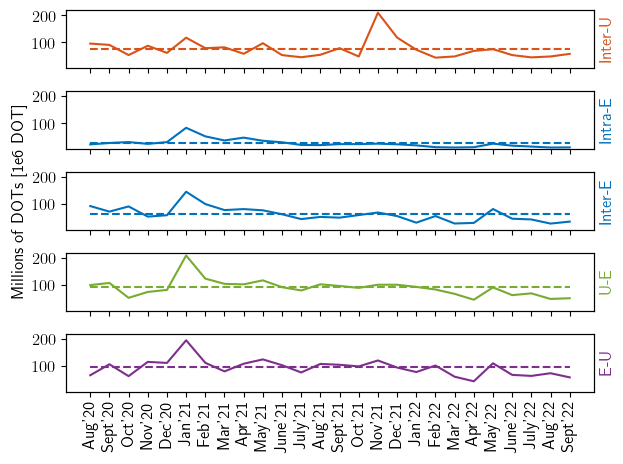

In [17]:
fig, axs = plt.subplots(5, 1, sharex=True)

data = {
    'intra-users' : f_uu_qs,
    'intra-exchanges' : f_ee_intra_qs,
    'inter-exchanges' : f_ee_inter_qs,
    'user-exchange' : f_ue_qs,
    'exchange-user' : f_eu_qs
}

data_ref = {
    'intra-users' : f_uu/nq,
    'intra-exchanges' : f_ee_intra/nq,
    'inter-exchanges' : f_ee_inter/nq,
    'user-exchange' : f_ue/nq,
    'exchange-user' : f_eu/nq
}

cols = {
    'intra-users' : UU_color,
    'intra-exchanges' : EE_color,
    'inter-exchanges' : EE_color,
    'user-exchange' : UE_color,
    'exchange-user' : EU_color
}

orders = {
    'intra-users' : 0,
    'intra-exchanges' : 1,
    'inter-exchanges' : 2,
    'user-exchange' : 3,
    'exchange-user' : 4
}

labels = {
    'intra-users' : 'Inter-U',
    'intra-exchanges' : 'Intra-E',
    'inter-exchanges' : 'Inter-E',
    'user-exchange' : 'U-E',
    'exchange-user' : 'E-U'
}


for attribute, measurement in data.items():
    idx = orders[attribute]
    axs[idx].plot(measurement/1000000, color=cols[attribute])
    axs[idx].plot(np.ones(nq)*data_ref[attribute]/1000000, '--', color=cols[attribute])
    axt = axs[idx].twinx()
    axt.tick_params(
        axis='y',
        which='both',
        left=False,
        right=False,
        labelright=False
    )
    axt.set_ylabel(labels[attribute], color= cols[attribute])
    axs[idx].set_ylim([5, 220])

plt.xticks(ticks=range(nq), labels=qs)
axs[4].tick_params(axis='x', rotation=90)

axs[2].set_ylabel("Millions of DOTs [1e6 DOT]")

fig.tight_layout()

if do_export : fig.savefig(f'{imgfolder}/flux_monthly_total.png', dpi=fig.dpi*5)

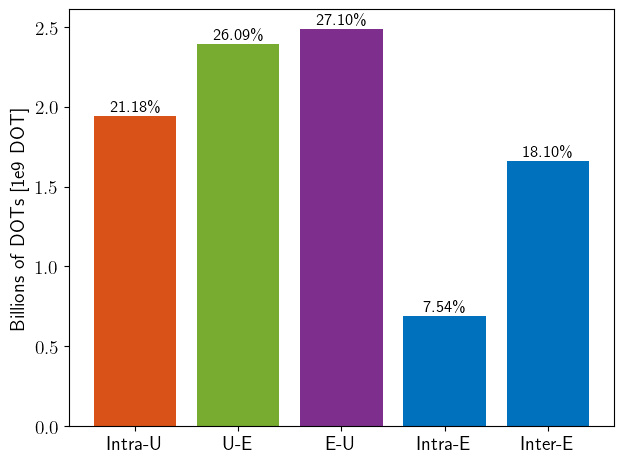

In [18]:
fig, ax = plt.subplots()

factor = 1000000000
sizes  = [f_uu, f_ue, f_eu, f_ee_intra, f_ee_inter]
sizes  = [x/factor for x in sizes]
perc   = [x/sum(sizes) for x in sizes]
labels = [
    f'Intra-U',
    f'U-E',
    f'E-U',
    f'Intra-E',
    f'Inter-E',
]
colors = [UU_color, UE_color, EU_color, EE_color, EE_color]
rects = ax.bar(
    np.arange(0,5),
    sizes,
    color=colors,
    tick_label=labels
)
ax.bar_label(rects, labels=[f"{100*x:.2f}\\%" for x in perc], padding=1, color='black')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
    
ax.set_ylabel('Billions of DOTs [1e9 DOT]')

fig.tight_layout()
if do_export: fig.savefig(f'{imgfolder}/distribution_ef_v4.png', dpi=fig.dpi*5)

## Statistics of the inter- and intra-cluster interactions -- Number of transactions (Fig.6)

In [19]:
m_uu_qs = np.array([
    sum([G1s[iq].nodes[i]['aec'] for i in range(N1s[iq]) if G1s[iq].nodes[i]['c']==0 and G1s[iq].nodes[i]['avc']>0])
    for iq in range(nq)
])
m_ee_inter_qs = np.array([
    sum([G1s[iq].nodes[i]['aec'] for i in range(N1s[iq]) if G1s[iq].nodes[i]['c']!=0]) for iq in range(nq)
])
m_ee_intra_qs = np.array([
    sum([
        c for (i, j, c) in G1s[iq].edges.data('ec')
        if c is not None and G1s[iq].nodes[i]['c'] > 0 and G1s[iq].nodes[j]['c'] > 0
    ]) 
    for iq in range(nq)
])
m_ee_qs = f_ee_inter_qs + f_ee_intra_qs
m_eu_qs = np.array([
    sum([
        c for (i, j, c) in G1s[iq].edges.data('ec')
        if c is not None and G1s[iq].nodes[i]['c'] > 0 and G1s[iq].nodes[j]['c'] == 0
    ])
    for iq in range(nq)
])
m_ue_qs = np.array([
    sum([
        c for (i, j, c) in G1s[iq].edges.data('ec')
        if c is not None and G1s[iq].nodes[i]['c'] == 0 and G1s[iq].nodes[j]['c'] > 0
    ])
    for iq in range(nq)
])


m_uu = sum([G1.nodes[i]['aec'] for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']>0])
m_ee_inter = sum([G1.nodes[i]['aec'] for i in range(N1) if G1.nodes[i]['c']!=0])
m_ee_intra = sum([
    c for (i, j, c) in G1.edges.data('ec')
    if c is not None and G1.nodes[i]['c'] > 0 and G1.nodes[j]['c'] > 0
])
m_ee = m_ee_intra + m_ee_inter
m_eu = sum([
    c for (i, j, c) in G1.edges.data('ec')
    if c is not None and G1.nodes[i]['c'] > 0 and G1.nodes[j]['c'] == 0
])
m_ue = sum([
    c for (i, j, c) in G1.edges.data('ec')
    if c is not None and G1.nodes[i]['c'] == 0 and G1.nodes[j]['c'] > 0
])

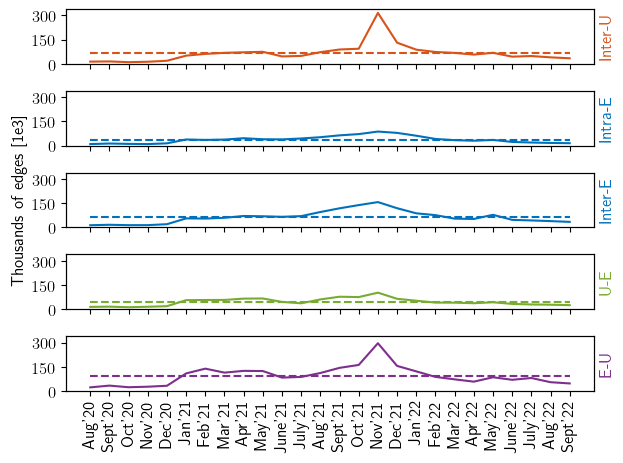

In [20]:
fig, axs = plt.subplots(5, 1, sharex=True)

data = {
    'intra-users' : m_uu_qs,
    'intra-exchanges' : m_ee_intra_qs,
    'inter-exchanges' : m_ee_inter_qs,
    'user-exchange' : m_ue_qs,
    'exchange-user' : m_eu_qs
}

data_ref = {
    'intra-users' : m_uu/nq,
    'intra-exchanges' : m_ee_intra/nq,
    'inter-exchanges' : m_ee_inter/nq,
    'user-exchange' : m_ue/nq,
    'exchange-user' : m_eu/nq
}

cols = {
    'intra-users' : UU_color,
    'intra-exchanges' : EE_color,
    'inter-exchanges' : EE_color,
    'user-exchange' : UE_color,
    'exchange-user' : EU_color
}

orders = {
    'intra-users' : 0,
    'intra-exchanges' : 1,
    'inter-exchanges' : 2,
    'user-exchange' : 3,
    'exchange-user' : 4
}

labels = {
    'intra-users' : 'Inter-U',
    'intra-exchanges' : 'Intra-E',
    'inter-exchanges' : 'Inter-E',
    'user-exchange' : 'U-E',
    'exchange-user' : 'E-U'
}



for attribute, measurement in data.items():
    idx = orders[attribute]
    axs[idx].plot(measurement/1000, color=cols[attribute])
    axs[idx].plot(np.ones(nq)*data_ref[attribute]/1000, '--', color=cols[attribute])
    axt = axs[idx].twinx()
    axt.tick_params(
        axis='y',
        which='both',
        left=False,
        right=False,
        labelright=False
    )
    axt.set_ylabel(labels[attribute], color= cols[attribute])
    axs[idx].set_ylim([0, 340])
    axs[idx].set_yticks([0, 150, 300])

plt.xticks(ticks=range(nq), labels=qs)
axs[4].tick_params(axis='x', rotation=90)
axs[2].set_ylabel('Thousands of edges [1e3]')

fig.tight_layout()

if do_export : fig.savefig(f'{imgfolder}/edges_monthly_amount.png', dpi=fig.dpi*5)

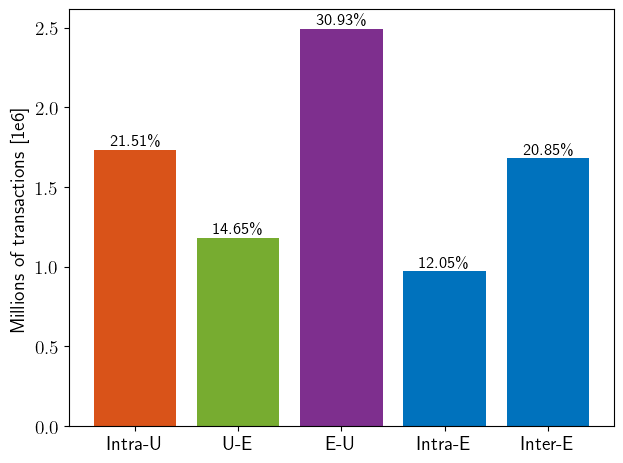

In [21]:
fig, ax = plt.subplots()
factor = 1000000
sizes  = [m_uu, m_ue, m_eu, m_ee_intra, m_ee_inter]
sizes  = [x/factor for x in sizes]
perc   = [x/sum(sizes) for x in sizes]
labels = [
    f'Intra-U',
    f'U-E',
    f'E-U',
    f'Intra-E',
    f'Inter-E',
]
colors = [UU_color, UE_color, EU_color, EE_color, EE_color]
rects = ax.bar(
    np.arange(0,5),
    sizes,
    color=colors,
    tick_label=labels
)
ax.bar_label(rects, labels=[f"{100*x:.2f}\\%" for x in perc], padding=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
    
ax.set_ylabel('Millions of transactions [1e6]')

fig.tight_layout()
if do_export: fig.savefig(f'{imgfolder}/distribution_ec_v4.png', dpi=fig.dpi*5)

## Distribution of the intra-cluster transactions for the top ten exchanges in size (Fig.7)

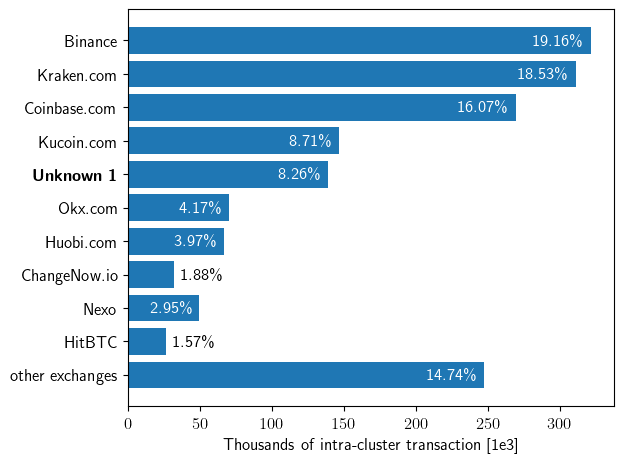

In [22]:
factor = 1000
sizes  = [G1.nodes[i]['aec']/factor for i in ecls_top_10]
tot_size = sum([G1.nodes[i]['aec'] for i in ecls_all])/factor
sizes  = sizes + [tot_size - sum(sizes)]
percentages = [f"{size/tot_size*100:4.2f}\\%" for size in sizes]
colors = [EE_color for i in range(len(sizes))]
labels = [names[G1.nodes[i]['c']] for i in ecls_top_10] + ["other exchanges"]

fig, ax = plt.subplots()

y_pos = np.arange(len(sizes))
ax.barh(y_pos, sizes, align='center')
ax.set_yticks(y_pos, labels=labels)
ax.invert_yaxis()
ax.set_xlabel('Thousands of intra-cluster transaction [1e3]')

for bar, perc in zip(ax.patches, percentages):
    if bar.get_width() < 40:
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2, perc, color = 'black', ha = 'left', va = 'center') 
    else:
        ax.text(bar.get_width()-5, bar.get_y()+bar.get_height()/2, perc, color = 'white', ha = 'right', va = 'center') 

fig.tight_layout()

if do_export: fig.savefig(f'{imgfolder}/distribution_ec_EE.pdf')

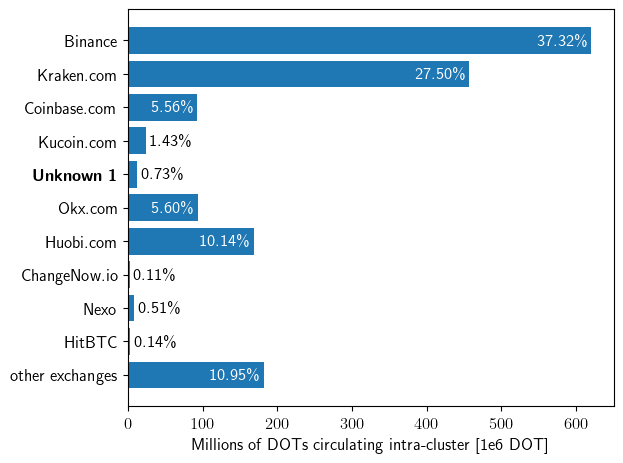

In [23]:
factor = 1000000
sizes  = [G1.nodes[i]['aef']/factor for i in ecls_top_10]
tot_size = sum([G1.nodes[i]['aef'] for i in ecls_all])/factor
sizes  = sizes + [tot_size - sum(sizes)]
percentages = [f"{size/tot_size*100:4.2f}\\%" for size in sizes]
colors = [EE_color for i in range(len(sizes))]
labels = [names[G1.nodes[i]['c']] for i in ecls_top_10] + ["other exchanges"]

fig, ax = plt.subplots()

y_pos = np.arange(len(sizes))
ax.barh(y_pos, sizes, align='center')
ax.set_yticks(y_pos, labels=labels)
ax.invert_yaxis()
ax.set_xlabel('Millions of DOTs circulating intra-cluster [1e6 DOT]')

for bar, perc in zip(ax.patches, percentages):
    if bar.get_width() < 40:
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2, perc, color = 'black', ha = 'left', va = 'center') 
    else:
        ax.text(bar.get_width()-5, bar.get_y()+bar.get_height()/2, perc, color = 'white', ha = 'right', va = 'center') 

fig.tight_layout()

if do_export: fig.savefig(f'{imgfolder}/distribution_ef_EE.pdf')

## Exchanges ecosystem mutual interactions within the contracted graph (Fig.8)

[[ 0  9]
 [ 0 10]
 [ 0 15]
 [ 9  0]
 [ 9 10]
 [10  0]
 [15  0]]


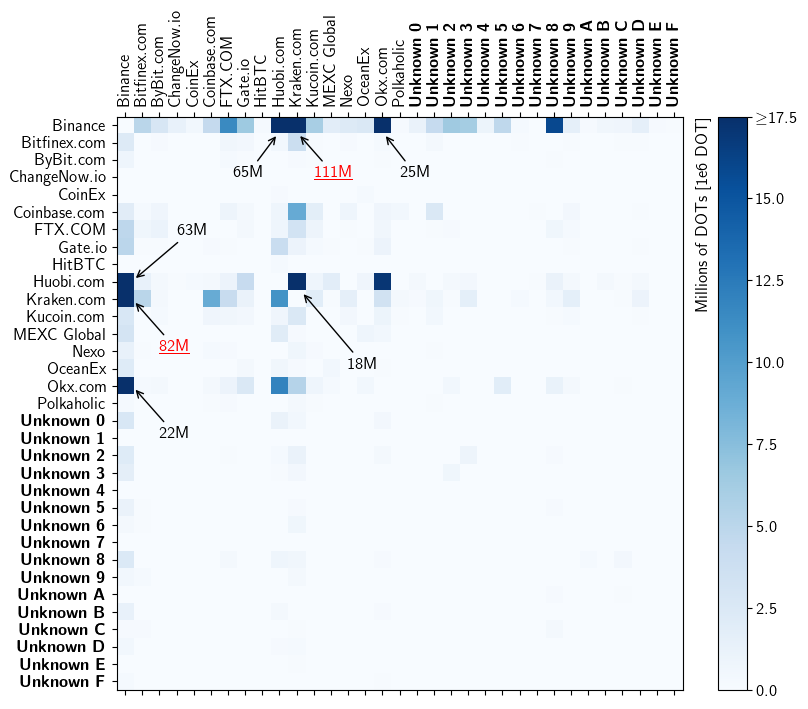

In [24]:
tmp = [i for i in range(N1) if G1.nodes[i]['c']>0]
Gplot = G1.subgraph(tmp)
labels  = {i : names[Gplot.nodes[i]['c']] for i in Gplot.nodes()}

sorted_nodes = sorted(Gplot.nodes(), key=lambda i: labels[i])
adj_matrix = nx.to_numpy_array(Gplot, nodelist=sorted_nodes, weight='ef')

cut = 17500000
adj_matrix_clip = np.clip(adj_matrix, 0, cut)

print(np.argwhere(adj_matrix>cut))

(fig, ax) = plt.subplots( figsize=(8.5, 7.25) )
cax = ax.matshow(adj_matrix_clip/1000000, cmap='Blues', aspect='auto')
ax.set_xticks(ticks=np.arange(len(sorted_nodes)), labels=[labels[i] for i in sorted_nodes])
ax.set_yticks(ticks=np.arange(len(sorted_nodes)), labels=[labels[i] for i in sorted_nodes])
ax.tick_params(axis='x', rotation=90)

ax.set_ylabel("Millions of DOTs [1e6 DOT]")
ax.yaxis.set_label_coords(1.05, 0.87)
ax.yaxis.set_label_coords(1.05, 0.83)

cbar = fig.colorbar(cax)
yticks = np.arange(0, 18, 2.5)
ylabels = [f"{tick}" for tick in yticks]
ylabels[-1] = f"$\\geq${ylabels[-1]}"
cbar.set_ticks(yticks, labels=ylabels)

ax.annotate(f"{round(adj_matrix[0,9]/1000000)}M",
            xy=(8.9, 0.5), xytext=(6.3, 3), arrowprops=dict(arrowstyle="->"))

ax.annotate(f"\\underline{{{round(adj_matrix[0,10]/1000000)}M}}",
            xy=(10.1, 0.5), xytext=(11, 3), arrowprops=dict(arrowstyle="->"), color='red')

ax.annotate(f"{round(adj_matrix[0,15]/1000000)}M",
            xy=(15.1, 0.5), xytext=(16, 3), arrowprops=dict(arrowstyle="->"))

ax.annotate(f"{round(adj_matrix[9,10]/1000000)}M",
            xy=(10.3, 9.6), xytext=(13, 14), arrowprops=dict(arrowstyle="->"))

ax.annotate(f"{round(adj_matrix[9,0]/1000000)}M",
            xy=(0.5, 8.9), xytext=(3, 6.3), arrowprops=dict(arrowstyle="->"))

ax.annotate(f"\\underline{{{round(adj_matrix[10,0]/1000000)}M}}",
            xy=(0.5, 10.1), xytext=(2, 13), arrowprops=dict(arrowstyle="->"), color='red')

ax.annotate(f"{round(adj_matrix[15,0]/1000000)}M",
            xy=(0.5, 15.1), xytext=(2, 18), arrowprops=dict(arrowstyle="->"))

fig.tight_layout()

if do_export : fig.savefig(f'{imgfolder}/adjacency_matrix_ef_EE.png', dpi=fig.dpi*5)

## Distribution of the nodes in the original network G (Fig.9)

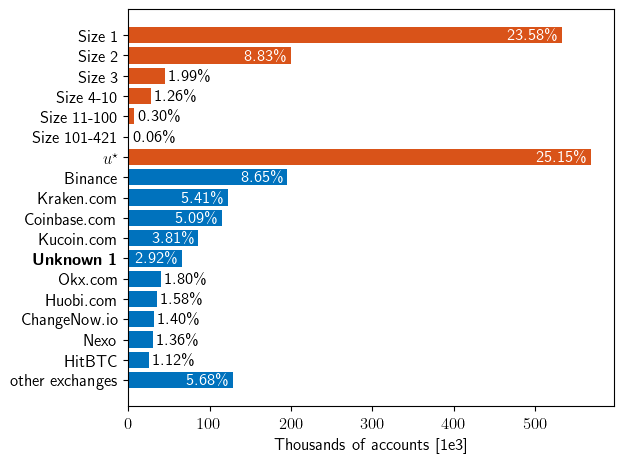

In [25]:
factor = 1000
sizesU = [uvc_1, uvc_2, uvc_3, uvc_10, uvc_100, uvc_421, uvc_big]
sizesE = [G1.nodes[i]['avc']/factor for i in ecls_top_10]
sizes  = [x/factor for x in sizesU] + sizesE
tot_size = sum([G1.nodes[i]['avc'] for i in G1.nodes()])/factor
sizes  = sizes + [tot_size - sum(sizes)]
percentages = [f"{size/tot_size*100:4.2f}\\%" for size in sizes]
colors = [UU_color for i in range(len(sizesU))] + [EE_color for i in range(len(sizesE)+1)]
labels = [
    'Size 1',
    'Size 2',
    'Size 3',
    'Size 4-10',
    'Size 11-100',
    'Size 101-421',
    '$u^\\star$'
] + [names[G1.nodes[i]['c']] for i in ecls_top_10] + ["other exchanges"]

fig, ax = plt.subplots()

y_pos = np.arange(len(sizes))
ax.barh(y_pos, sizes, align='center', color=colors)
ax.set_yticks(y_pos, labels=labels)
ax.invert_yaxis()
ax.set_xlabel('Thousands of accounts [1e3]')

for bar, perc in zip(ax.patches, percentages):
    if bar.get_width() < 50:
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2, perc, color = 'black', ha = 'left', va = 'center') 
    else:
        ax.text(bar.get_width()-5, bar.get_y()+bar.get_height()/2, perc, color = 'white', ha = 'right', va = 'center') 

fig.tight_layout()

if do_export: fig.savefig(f'{imgfolder}/distribution_vc.pdf')

## Distribution of the user clusters with respect to their size (Fig.10)

/var/folders/dx/cwr6shhx4sn8hfw99fzym7wm0000gn/T/ipykernel_14812/4257703666.py:36: RuntimeWarning: Mean of empty slice
  meanval = np.nanmean(ucs_xx, axis=0)
/Users/eliaonofri/Documents/Ricerca/Progetti/Lombardi/graphcontraction/aux-code/python/tmp/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


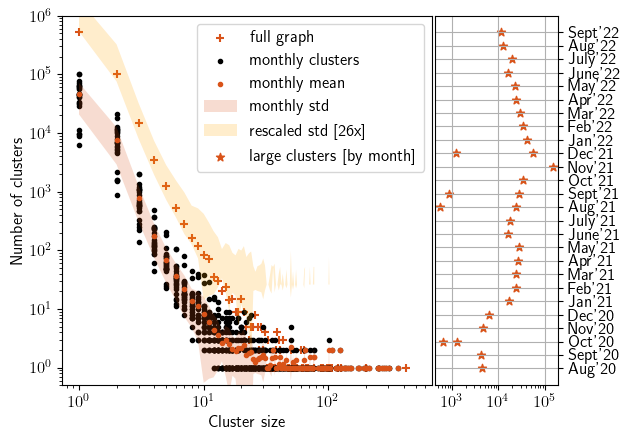

In [26]:
fig, axs = plt.subplots(1,2, gridspec_kw={'width_ratios': [3, 1], 'wspace':0.01, 'hspace':0})

uc_xx = np.zeros(500)
for i in range(N1):
    if G1.nodes[i]['c'] == 0 and G1.nodes[i]['avc'] < 450:
        uc_xx[G1.nodes[i]['avc']] = uc_xx[G1.nodes[i]['avc']] + 1 # G1.nodes[i]['avc']

ucs_xx = np.zeros([nq, 500])
for j in range(nq):
    for i in range(N1s[j]):
        if G1s[j].nodes[i]['c'] == 0 and G1s[j].nodes[i]['avc'] < 500:
            ucs_xx[j][G1s[j].nodes[i]['avc']] = ucs_xx[j][G1s[j].nodes[i]['avc']] + 1 # G1s[j].nodes[i]['avc']

ucs_xx[ucs_xx == 0] = np.nan
            
def func_powerlaw(x, k, a, c):
    return c + x**k * a
popt      = np.array([-4.7351,9869993.19,1])
label_tag = f'fit $y = {popt[1]:.2f}\\cdot x^{{{popt[0]:.2f}}} + {popt[2]:.2f}$'

def func_powerlaw(x, k, a, h):
    return 1 + (x/h)**k * a
popt      = np.array([-4.7351,1,30])
label_tag = f'fit $y = {popt[1]:.2f}\\cdot (x/{popt[2]:.2f})^{{{popt[0]:.2f}}} + {1}$'

def func_powerlaw(x, k, h):
    return 1 + (x/h)**(k)
popt      = np.array([-4.7351,29.972])
label_tag = f'fit $y = (x/{popt[1]:.2f})^{{{popt[0]:.2f}}} + {1}$'

xx = np.arange(len(uc_xx))
xxs = [np.arange(len(uc_xx)) for _ in range(nq)]

ax = axs[0]

meanval = np.nanmean(ucs_xx, axis=0)
stdval  = np.nanstd(ucs_xx, axis=0)


sct_full = ax.scatter(
    xx,
    uc_xx,
    marker='+',
    color = UU_color,
    label='full graph'
)

sct_month = ax.scatter(xxs, ucs_xx, marker='.', color='k', label='monthly clusters')
sct_mean = ax.scatter(xx, meanval, marker='.', color=UU_color, label='monthly mean')
fill_std = ax.fill_between(xx, meanval-stdval, meanval+stdval, alpha=.2, facecolor=UU_color, label="monthly std")
fill_26 = ax.fill_between(xx, nq*(meanval-stdval), nq*(meanval+stdval), alpha=.2, facecolor=UU4_color, label=f"rescaled std [{nq}x]")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim([0.5, 1000000])
ax.set_xlabel('Cluster size')
ax.set_ylabel('Number of clusters')

ax = axs[1]

larger_cls = [
    [
        G1s[j].nodes[i]['avc']
        for i in range(N1s[j])
        if G1s[j].nodes[i]['c'] == 0
        and G1s[j].nodes[i]['avc'] >= 421
    ]
    for j in range(nq)
]
xx_cls = [[i for _ in range(len(x))] for (i, x) in enumerate(larger_cls)]
for i in range(nq):
    sct_big = ax.scatter(larger_cls[i], xx_cls[i], color=UU_color, marker='*', label="large clusters [by month]")
ax.set_xscale('log')
ax.grid(axis='both')

ax.yaxis.tick_right()
ax.set_yticks(ticks=range(nq), labels=qs)

axs[0].legend(handles=[sct_full, sct_month, sct_mean, fill_std, fill_26, sct_big])

if do_export: fig.savefig(f'{imgfolder}/distribution_avc_UU_v3.png', dpi=300)

## Total number of active nodes within ustar in terms of months of enrollment (Fig.11)

In [27]:
tmp = [i for i in range(N1) if G1.nodes[i]['c']==0 and G1.nodes[i]['avc']==568823]
assert(len(tmp) == 1)
idxustar = tmp[0]

Hustar = [k for (k, v) in H_2_V1.items() if v == idxustar]

ustarpresence = np.zeros((nq, len(Hustar)))
for i in range(nq):
    for j in range(len(Hustar)):
        if Hustar[j] in H_2_V1s[i].keys():
            ustarpresence[i][j] = 1

ustarpresence1 = np.transpose(ustarpresence)

ustarTimeInteraction = np.zeros((nq, nq))
for i in range(len(ustarpresence1)):
    if sum(ustarpresence1[i]) != 0:
        firstnnz = np.nonzero(ustarpresence1[i])[0][0]
        ustarTimeInteraction[firstnnz] += ustarpresence1[i]


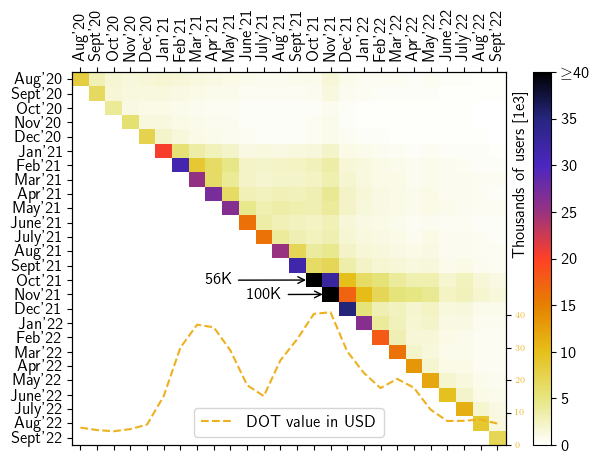

In [28]:
(fig, ax) = plt.subplots()
cax = ax.matshow(ustarTimeInteraction/1000, cmap='CMRmap_r', aspect='auto', vmin=0, vmax=40)
ax.set_xticks(ticks=range(nq), labels=qs)
ax.set_yticks(ticks=range(nq), labels=qs)
ax.tick_params(axis='x', rotation=90)
cbar = fig.colorbar(cax)
yticks = np.arange(0, 41, 5)
ylabels = [f"{tick}" for tick in yticks]
ylabels[-1] = f"$\\geq${ylabels[-1]}"
cbar.set_ticks(yticks, labels=ylabels)

ax.set_ylabel("Thousands of users [1e3]")
ax.yaxis.set_label_coords(1.0525, 0.725)

ax.annotate(f"{round(ustarTimeInteraction[14,14]/1000)}K",
            xy=(13.7, 14), xytext=(7.5, 14.3), arrowprops=dict(arrowstyle="->"))

ax.annotate(f"{round(ustarTimeInteraction[15,15]/1000)}K",
            xy=(14.7, 15), xytext=(10, 15.3), arrowprops=dict(arrowstyle="->"))

axt = ax.twinx()
axt.plot(dot2usd, '--', label="DOT value in USD", color=greenUSD)
axt.legend(loc=8)
axt.tick_params(axis='y', labelcolor=greenUSD)
axt.tick_params(axis='y', which='major', labelsize=6)
axt.set_ylim([0, 115])
axt.set_yticks(ticks=[0, 10, 20, 30, 40])

ax.autoscale(False)
axt.autoscale(False)

fig.tight_layout()

if do_export : fig.savefig(f'{imgfolder}/monthly_returning_nodes_v2.png', dpi=fig.dpi*5)

## Monthly distribution of the novel-enrolled nodes that interact with pre-existing nodes of the network (Fig.12)

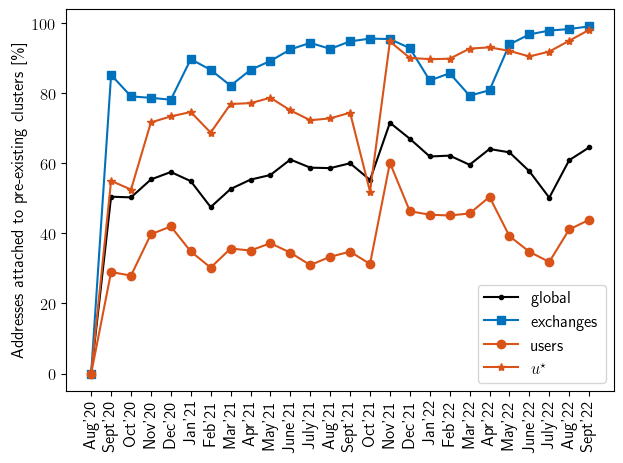

In [29]:
Husers = [k for (k, v) in H_2_V1.items() if G1.nodes()[v]['c'] == 0]

ratioV = np.zeros(nq)
allnodes = set()
for i in range(nq):
    currnodes = set(H_2_V1s[i].keys())
    novel     = currnodes - allnodes
    old       = currnodes - novel
    allnodes  = allnodes | currnodes
    V1s_contains_old = np.zeros(G1s[i].order())
    for u in old:
        V1s_contains_old[H_2_V1s[i][u]] = 1
    for u in novel:
        ratioV[i] += V1s_contains_old[H_2_V1s[i][u]]
    ratioV[i] /= len(novel)
    
ratioE = np.zeros(nq)
allnodes = set()
for i in range(nq):
    currnodes = set(H_2_V1s[i].keys()) - set(Husers)
    novel     = currnodes - allnodes
    old       = currnodes - novel
    allnodes  = allnodes | currnodes
    V1s_contains_old = np.zeros(G1s[i].order())
    for u in old:
        V1s_contains_old[H_2_V1s[i][u]] = 1
    for u in novel:
        ratioE[i] += V1s_contains_old[H_2_V1s[i][u]]
    ratioE[i] /= len(novel)

ratioU = np.zeros(nq)
allnodes = set()
for i in range(nq):
    currnodes = set(H_2_V1s[i].keys()) & set(Husers)
    novel     = currnodes - allnodes
    old       = currnodes - novel
    allnodes  = allnodes | currnodes
    V1s_contains_old = np.zeros(G1s[i].order())
    for u in old:
        V1s_contains_old[H_2_V1s[i][u]] = 1
    for u in novel:
        ratioU[i] += V1s_contains_old[H_2_V1s[i][u]]
    ratioU[i] /= len(novel)
    
ratioUs = np.zeros(nq)
allnodes = set()
for i in range(nq):
    currnodes = set(H_2_V1s[i].keys()) & set(Hustar)
    novel     = currnodes - allnodes
    old       = currnodes - novel
    allnodes  = allnodes | currnodes
    V1s_contains_old = np.zeros(G1s[i].order())
    for u in old:
        V1s_contains_old[H_2_V1s[i][u]] = 1
    for u in novel:
        ratioUs[i] += V1s_contains_old[H_2_V1s[i][u]]
    ratioUs[i] /= len(novel)


fig, ax = plt.subplots()
ax.plot(ratioV*100, label='global', color='k', marker='.')
ax.plot(ratioE*100, label='exchanges', color=EE_color, marker='s')
ax.plot(ratioU*100, label='users', color=UU_color, marker='o')
ax.plot(ratioUs*100, label='$u^\\star$', color=UU_color, marker='*')

ax.set_ylabel('Addresses attached to pre-existing clusters [\\%]')
ax.legend()
plt.xticks(ticks=range(nq), labels=qs)
ax.tick_params(axis='x', rotation=90)

fig.tight_layout()

if do_export : fig.savefig(f'{imgfolder}/monthly_clustering_growing.png', dpi=fig.dpi*5)

## Chord plot depicting the transaction distribution from and to the various exchange services, as operated from ustar (Fig.13)

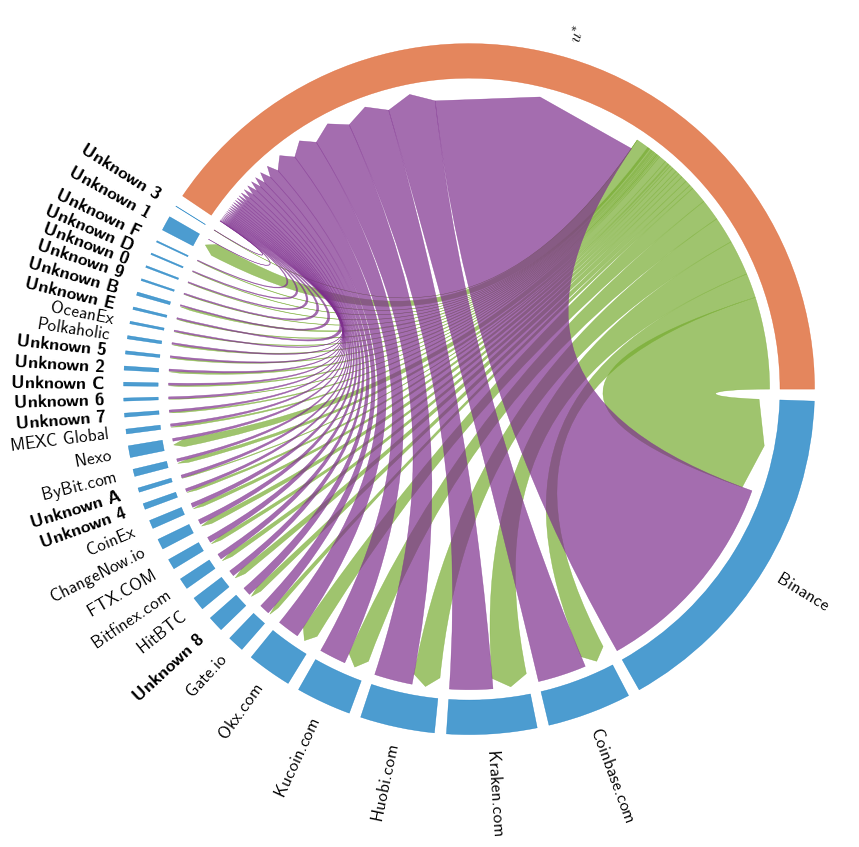

In [30]:
tmp = [i for i in range(N1) if (G1.nodes[i]['avc']>=500 and G1.degree(i) != 0) or G1.nodes[i]['c']>0]
Gplot = G1.subgraph(tmp)
Gplot.order()
labels  = {i : names[Gplot.nodes[i]['c']] for i in Gplot.nodes()}

node_list = list(Gplot.nodes())
labels_val = [names[Gplot.nodes[i]['c']] for i in node_list]
srt_val = [Gplot[u][2]['ec'] if 2 in Gplot[u] else 0000000000 for u in node_list]
srt = [i[0] for i in sorted(enumerate(srt_val), key=lambda x:x[1], reverse=False)]
node_list = [node_list[srt[i]] for i in range(len(node_list))]
node_index = {n: i for i, n in enumerate(node_list)}
edges = [(node_index[i], node_index[j], Gplot.edges[i, j]['ec']) for i, j in Gplot.edges()]

node_labels = [labels[i] for i in node_list]

special_node = next(i for i in node_list if Gplot.nodes[i]['c'] == 0)
special_idx = node_index[special_node]
node_labels[special_idx] = r"$u^*$"

N = len(node_list)
adj_matrix = np.zeros((N, N))
for i, j, weight in edges:
    if i == special_idx or j == special_idx:
        adj_matrix[i, j] = weight


node_colours = [EE_color if i != special_idx else UU_color for i in range(N)]

chord_colors = [
    (plt.cm.Grays(i / len(adj_matrix))
    if i == special_idx else plt.cm.Blues(i / len(adj_matrix))
    ) for i in range(len(adj_matrix))
]
chord_colors = [
    (UU_color)
    if i == special_idx else plt.cm.Blues(.5 + i/N/2)
    for i in range(len(adj_matrix))
]
chord_colors = [
    UE_color
    if i == special_idx else EU_color
    for i in range(len(adj_matrix))
]


fig, ax = plt.subplots(figsize=(8, 8))
chord_diagram(
    adj_matrix,
    names=node_labels,
    ax=ax,
    sort="distance",
    colors=node_colours,
    directed=True,
    chord_colors=chord_colors,
    alpha=.7
)

for label in ax.texts:
    angle = float(label.get_rotation())
    angle = (angle + 90) % 360
    if angle > 90 and angle < 180:
        label.set_rotation(angle +180)
    else:
        label.set_rotation(angle)
    x, y = label.get_position()
    if x < 0:
        label.set_ha("right")
    else:
        label.set_ha("left")
    label.set_va("center")

if do_export : fig.savefig(f'{imgfolder}/chord_diagram_ec_UE.png', dpi=fig.dpi*5, bbox_inches='tight')

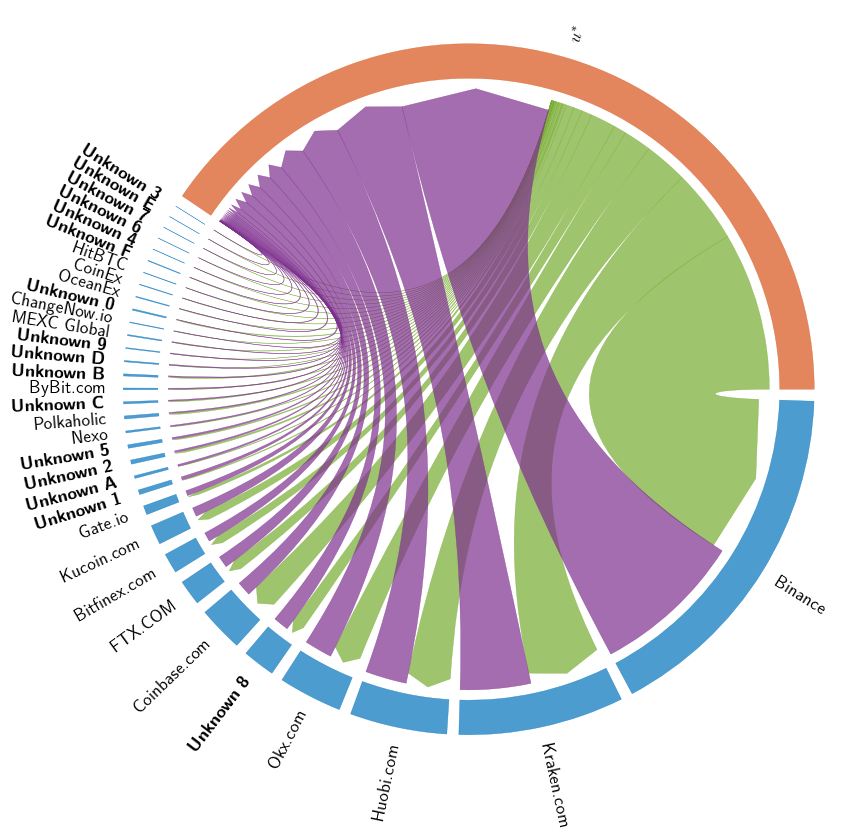

In [31]:
tmp = [i for i in range(N1) if (G1.nodes[i]['avc']>=500 and G1.degree(i) != 0) or G1.nodes[i]['c']>0]
Gplot = G1.subgraph(tmp)
Gplot.order()

node_list = list(Gplot.nodes())
labels_val = [names[Gplot.nodes[i]['c']] for i in node_list]
srt_val = [Gplot[u][2]['ef'] if 2 in Gplot[u] else 0000000000 for u in node_list]
srt = [i[0] for i in sorted(enumerate(srt_val), key=lambda x:x[1], reverse=False)]
node_list = [node_list[srt[i]] for i in range(len(node_list))]
node_index = {n: i for i, n in enumerate(node_list)}
edges = [(node_index[i], node_index[j], Gplot.edges[i, j]['ef']) for i, j in Gplot.edges()]

node_labels = [labels[i] for i in node_list]

special_node = next(i for i in node_list if Gplot.nodes[i]['c'] == 0)
special_idx = node_index[special_node]
node_labels[special_idx] = r"$u^*$"

N = len(node_list)
adj_matrix = np.zeros((N, N))
for i, j, weight in edges:
    if i == special_idx or j == special_idx:
        adj_matrix[i, j] = weight

node_colours = [EE_color if i != special_idx else UU_color for i in range(N)]

chord_colors = [
    (plt.cm.Grays(i / len(adj_matrix))
    if i == special_idx else plt.cm.Blues(i / len(adj_matrix))
    ) for i in range(len(adj_matrix))
]
chord_colors = [
    (UU_color)
    if i == special_idx else plt.cm.Blues(.5 + i/N/2)
    for i in range(len(adj_matrix))
]

chord_colors = [
    UE_color
    if i == special_idx else EU_color
    for i in range(len(adj_matrix))
]

fig, ax = plt.subplots(figsize=(8, 8))
chord_diagram(
    adj_matrix,
    names=node_labels,
    ax=ax,
    sort="distance",
    colors=node_colours,
    directed=True,
    chord_colors=chord_colors,
)

for label in ax.texts:
    angle = float(label.get_rotation())
    angle = (angle + 90) % 360
    if angle > 90 and angle < 180:
        label.set_rotation(angle +180)
    else:
        label.set_rotation(angle)
    x, y = label.get_position()
    if x < 0:
        label.set_ha("right")
    else:
        label.set_ha("left")
    label.set_va("center")

if do_export : fig.savefig(f'{imgfolder}/chord_diagram_ef_UE.png', dpi=fig.dpi*5, bbox_inches='tight')

## Top 10 Largest Exchange Services with Corresponding Statistics (Tab.2)

In [32]:
tmp = [G1.nodes[i] for i in ecls_all]
tot_avc = sum([x['avc'] for x in tmp])
tot_aec = sum([x['aec'] for x in tmp])
tot_aef = sum([x['aef'] for x in tmp])

kkk = [x['avc'] for x in tmp]
srt = [i[0] for i in sorted(enumerate(kkk), key=lambda x:x[1], reverse=True)]

for i in range(10):
    tmp1 = tmp[srt[i]]['avc']
    tmp2 = tmp[srt[i]]['aec']
    tmp3 = tmp[srt[i]]['aef']
    tmpc = tmp[srt[i]]['c']
    tmplist = [[G1s[t].nodes[u] for u in G1s[t].nodes() if G1s[t].nodes[u]['c'] == tmpc] for t in range(nq)]
    tmp11 = [sum([u['avc'] for u in ul]) for ul in tmplist]
    tmp12 = [sum([u['aec'] for u in ul]) for ul in tmplist]
    tmp13 = [sum([u['aef'] for u in ul]) for ul in tmplist]
    hlists = [set([h for (h, u) in H_2_V1s[t].items() if G1s[t].nodes[u]['c'] == tmpc]) for t in range(nq)]
    novels = np.zeros(nq)
    old = hlists[0]
    novels[0] = len(old)
    for t in range(1, nq):
        novels[t] = len(hlists[t] - old)
        old = old | hlists[t]
    
    print(
        f"\\multirow{{2}}{{*}}{{{names[tmp[srt[i]]['c']]}}} & "
        f"\\multirow{{2}}{{*}}{{?}} & "
        f"{tmp1} & "
        f"$\\mu$ = {np.mean(tmp11):.2f} & "
        f"$\\mu$ = {np.mean(novels):.2f} & "
        f"{tmp2} & "
        f"$\\mu$ = {np.mean(tmp12):.2f} & "
        f"{tmp3:.2f} &"
        f"$\\mu$ = {np.mean(tmp13):.2f} \\\\"
    )
    print(
        f" & "
        f" & "
        f"({tmp1/tot_avc*100:.2f}\\%) & "
        f"$\\sigma$ = {np.std(tmp11):.2f} & "
        f"$\\sigma$ = {np.std(novels):.2f} & "
        f"({tmp2/tot_aec*100:.2f}\\%) & "
        f"$\\sigma$ = {np.std(tmp12):.2f} & "
        f"({tmp3/tot_aef*100:.2f}\\%) & "
        f"$\\sigma$ = {np.std(tmp13):.2f} \\\\"
    )
    print("\\hline")

tmp1 = sum([tmp[srt[i]]['avc'] for i in range(10, len(kkk))])
tmp2 = sum([tmp[srt[i]]['aec'] for i in range(10, len(kkk))])
tmp3 = sum([tmp[srt[i]]['aef'] for i in range(10, len(kkk))])
tmpc = [tmp[srt[i]]['c'] for i in range(10, len(kkk))]
tmplist = [[G1s[t].nodes[u] for u in G1s[t].nodes() if G1s[t].nodes[u]['c'] in tmpc] for t in range(nq)]
tmp11 = [sum([u['avc'] for u in ul]) for ul in tmplist]
tmp12 = [sum([u['aec'] for u in ul]) for ul in tmplist]
tmp13 = [sum([u['aef'] for u in ul]) for ul in tmplist]
hlists = [set([h for (h, u) in H_2_V1s[t].items() if G1s[t].nodes[u]['c'] in tmpc]) for t in range(nq)]
novels = np.zeros(nq)
old = hlists[0]
novels[0] = len(old)
for t in range(1, nq):
    novels[t] = len(hlists[t] - old)
    old = old | hlists[t]

print(
    f"\\multirow{{2}}{{*}}{{other exch.}} & "
    f"\\multirow{{2}}{{*}}{{1--1}} & "
    f"{tmp1} & "
    f"$\\mu$ = {np.mean(tmp11):.2f} & "
    f"$\\mu$ = {np.mean(novels):.2f} & "
    f"{tmp2} & "
    f"$\\mu$ = {np.mean(tmp12):.2f} & "
    f"{tmp3:.2f} &"
    f"$\\mu$ = {np.mean(tmp13):.2f} \\\\"
)
print(
    f" & "
    f" & "
    f"({tmp1/tot_avc*100:.2f}\\%) & "
    f"$\\sigma$ = {np.std(tmp11):.2f} & "
    f"$\\sigma$ = {np.std(novels):.2f} & "
    f"({tmp2/tot_aec*100:.2f}\\%) & "
    f"$\\sigma$ = {np.std(tmp12):.2f} & "
    f"({tmp3/tot_aef*100:.2f}\\%) & "
    f"$\\sigma$ = {np.std(tmp13):.2f} \\\\"
)

\multirow{2}{*}{Binance} & \multirow{2}{*}{?} & 195678 & $\mu$ = 13125.31 & $\mu$ = 7473.27 & 321722 & $\mu$ = 12233.73 & 620116608.00 &$\mu$ = 23679188.14 \\
 &  & (22.29\%) & $\sigma$ = 6916.80 & $\sigma$ = 4392.45 & (19.16\%) & $\sigma$ = 8046.05 & (37.32\%) & $\sigma$ = 15960532.82 \\
\hline
\multirow{2}{*}{Kraken.com} & \multirow{2}{*}{?} & 122263 & $\mu$ = 7640.23 & $\mu$ = 4683.19 & 311118 & $\mu$ = 11875.50 & 456932096.00 &$\mu$ = 17504677.15 \\
 &  & (13.93\%) & $\sigma$ = 3943.08 & $\sigma$ = 2728.14 & (18.53\%) & $\sigma$ = 5839.91 & (27.50\%) & $\sigma$ = 7518876.99 \\
\hline
\multirow{2}{*}{Coinbase.com} & \multirow{2}{*}{?} & 115178 & $\mu$ = 4612.65 & $\mu$ = 4396.15 & 269823 & $\mu$ = 10268.00 & 92455408.00 &$\mu$ = 3522222.55 \\
 &  & (13.12\%) & $\sigma$ = 4671.66 & $\sigma$ = 4524.58 & (16.07\%) & $\sigma$ = 10223.65 & (5.56\%) & $\sigma$ = 3663824.85 \\
\hline
\multirow{2}{*}{Kucoin.com} & \multirow{2}{*}{?} & 86065 & $\mu$ = 4269.35 & $\mu$ = 3283.54 & 146344 & $\m